In [2]:
import os
import cv2
import numpy as np
import torch
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("backend:", matplotlib.get_backend())
print("CUDA available:", torch.cuda.is_available())

torch: 2.10.0+cu128
backend: module://matplotlib_inline.backend_inline
CUDA available: True


In [5]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("model loaded on:", device)

C:\Users\Carl\anaconda3\envs\OCR-ml\lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model loaded on: cuda


In [6]:
IMAGE_DIR = r"C:\Users\Carl\Python\Projects\OCR\data\testimages"

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
])

print(len(image_files))
print(image_files[:5])

27
['a01-000u.png', 'a01-003u.png', 'a01-007u.png', 'a01-011u.png', 'a01-014u.png']


In [7]:
def show(img, title=""):
    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(111)

    if img.ndim == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    ax.set_title(title)
    ax.axis("off")
    fig.canvas.draw()
    plt.show()

In [8]:
i = 1
img_path = os.path.join(IMAGE_DIR, image_files[i])
img_bgr = cv2.imread(img_path)

print("LOADING:", img_path)
print("NONE:", img_bgr is None)
print("SHAPE:", img_bgr.shape)
print("DTYPE:", img_bgr.dtype)
print("SUM:", int(img_bgr.sum()))

LOADING: C:\Users\Carl\Python\Projects\OCR\data\testimages\a01-003u.png
NONE: False
SHAPE: (3542, 2479, 3)
DTYPE: uint8
SUM: 2023857770


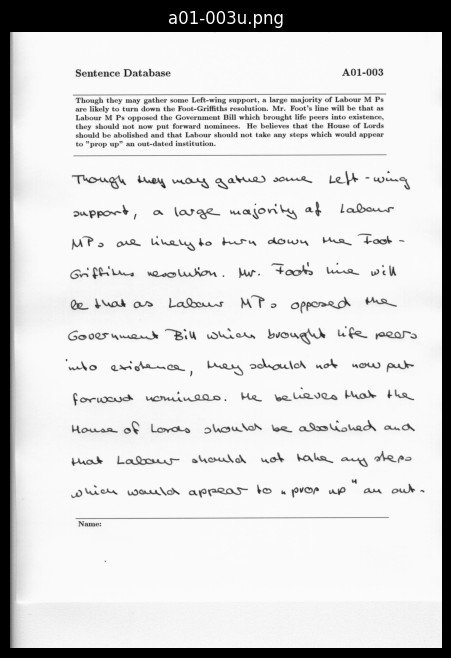

In [9]:
show(img_bgr, image_files[i])

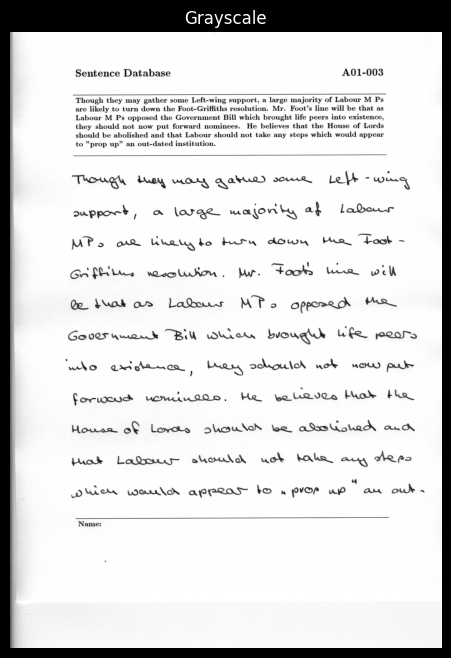

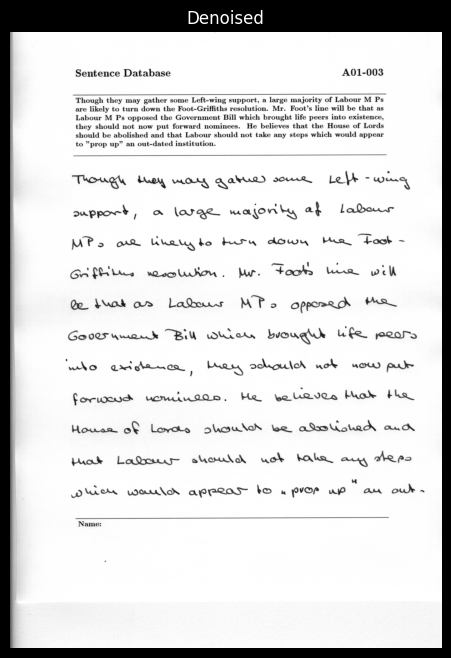

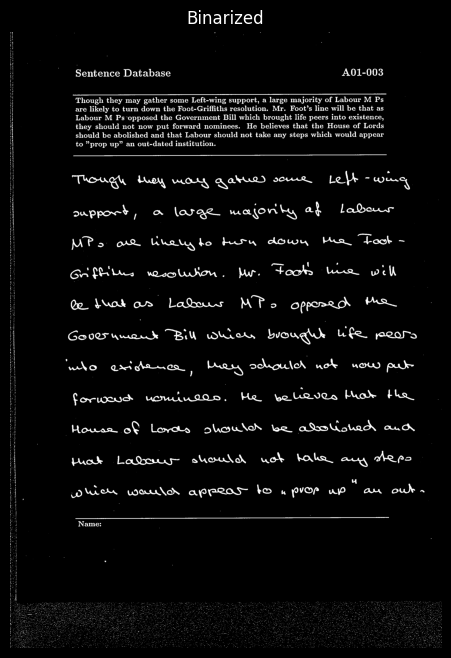

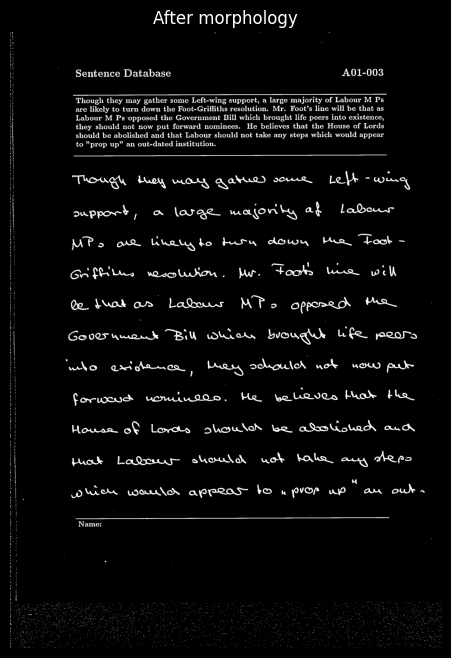

In [11]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
show(gray, "Grayscale")

gray_dn = cv2.GaussianBlur(gray, (3, 3), 0)
show(gray_dn, "Denoised")

bw = cv2.adaptiveThreshold(
    gray_dn, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31, 10
)
show(bw, "Binarized")

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
bw_clean = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=1)
show(bw_clean, "After morphology")

In [12]:
def crop_rois(img_bgr):
    h, w = img_bgr.shape[:2]

    roi_hand = img_bgr[int(0.21 * h):int(0.78 * h), int(0.08 * w):int(0.99 * w)]

    return roi_hand

ROI SUM: 3272762943
ROI SHAPE: (2019, 2256, 3)


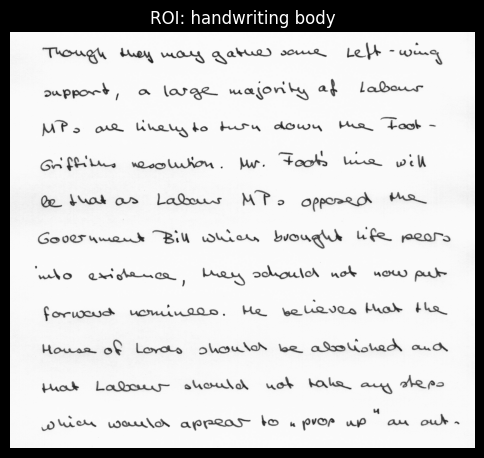

In [13]:
roi_hand = crop_rois(img_bgr)

print("ROI SUM:", int(roi_hand.sum()))
print("ROI SHAPE:", roi_hand.shape)

show(roi_hand, "ROI: handwriting body")

In [14]:
def tight_crop_to_ink(roi_bgr, pad=15, top_frac=0.0, bottom_frac=1.0):
    h_full, w_full = roi_bgr.shape[:2]

    y0_search = int(top_frac * h_full)
    y1_search = int(bottom_frac * h_full)

    if y1_search <= y0_search + 10:
        return roi_bgr

    roi_sub = roi_bgr[y0_search:y1_search, :]

    gray = cv2.cvtColor(roi_sub, cv2.COLOR_BGR2GRAY)
    bw = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 10
    )

    ys, xs = np.where(bw > 0)
    if xs.size == 0:
        return roi_sub

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    h, w = bw.shape
    x0 = max(x0 - pad, 0)
    x1 = min(x1 + pad, w - 1)
    y0 = max(y0 - pad, 0)
    y1 = min(y1 + pad, h - 1)

    y0_full = y0 + y0_search
    y1_full = y1 + y0_search

    return roi_bgr[y0_full:y1_full + 1, x0:x1 + 1]

In [15]:
def split_lines(roi_bgr, min_h=18, pad=6):
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    bw = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31, 10
    )

    proj = (bw > 0).sum(axis=1)

    if proj.max() == 0:
        return []

    thr = 0.12 * proj.max()
    mask = proj > thr

    bands = []
    in_band = False
    start = 0

    for i, v in enumerate(mask):
        if v and not in_band:
            in_band = True
            start = i
        elif not v and in_band:
            in_band = False
            end = i
            if end - start >= min_h:
                y0 = max(start - pad, 0)
                y1 = min(end + pad, bw.shape[0])
                bands.append((y0, y1))

    if in_band:
        end = len(mask)
        if end - start >= min_h:
            y0 = max(start - pad, 0)
            y1 = min(end + pad, bw.shape[0])
            bands.append((y0, y1))

    return [roi_bgr[y0:y1, :] for (y0, y1) in bands]

In [16]:
def trocr_ocr(img_bgr, max_length=128):
    if img_bgr.ndim == 2:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pixel_values = processor(images=img_rgb, return_tensors="pt").pixel_values.to(device)

    generated_ids = model.generate(pixel_values, max_length=max_length)
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return text.strip()

USING: C:\Users\Carl\Python\Projects\OCR\data\testimages\a01-003u.png
IMG SUM: 2023857770
ROI_HAND SUM: 3272762943


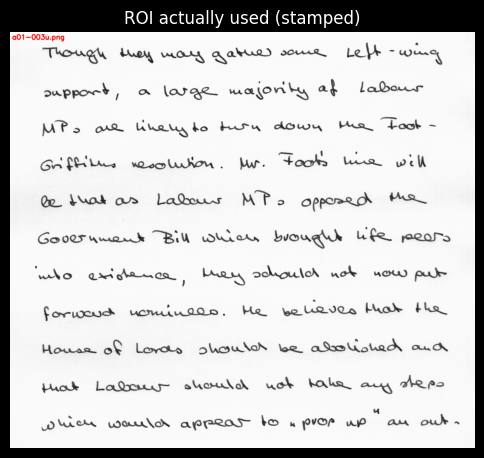

ROI_TIGHT SUM: 3272762943


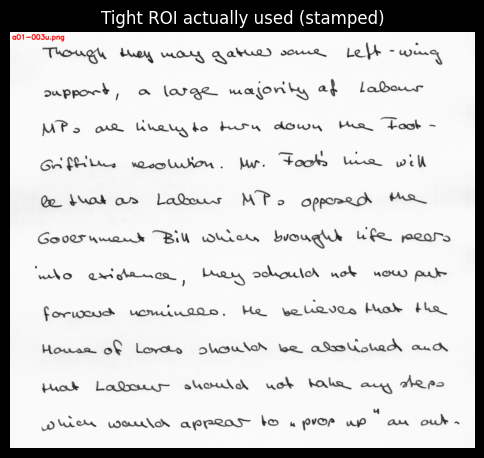

Num lines: 11


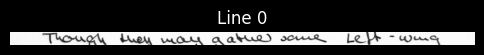

0 => '# Though they may gather some Left-wing'


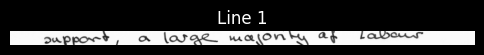

1 => 'support, a large majority of Labour...'


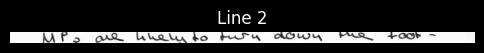

2 => '1UPs are likely to turn down the took -'


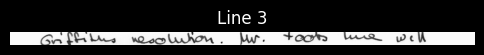

3 => 'Griffiths resolution. Mr. took the will'


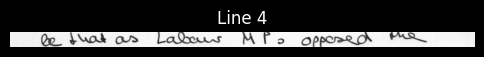

4 => 'be that as Labour MPs opposed the'


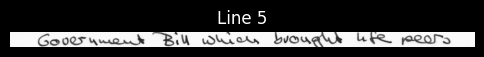

5 => 'Government Bill which brought life peers.'


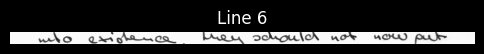

6 => 'into existence they should not now put'


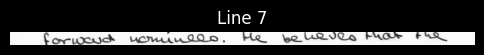

7 => 'forward nominees. He believes that the'


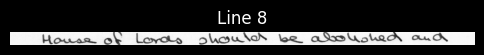

8 => '" House of Lords should be abolished and'


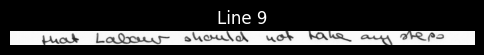

9 => '# that Labour should not take any steps'


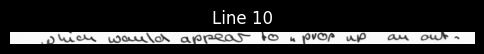

10 => 'which would appear to " prop up an out -'

FINAL:

# Though they may gather some Left-wing
support, a large majority of Labour...
1UPs are likely to turn down the took -
Griffiths resolution. Mr. took the will
be that as Labour MPs opposed the
Government Bill which brought life peers.
into existence they should not now put
forward nominees. He believes that the
" House of Lords should be abolished and
# that Labour should not take any steps
which would appear to " prop up an out -


In [17]:
idx = 1

img_path = os.path.join(IMAGE_DIR, image_files[idx])
img_bgr = cv2.imread(img_path)

print("USING:", img_path)
print("IMG SUM:", int(img_bgr.sum()))

roi_hand = crop_rois(img_bgr)
print("ROI_HAND SUM:", int(roi_hand.sum()))

tmp = roi_hand.copy()
cv2.putText(
    tmp,
    os.path.basename(img_path),
    (10, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.1,
    (0, 0, 255),
    3
)
show(tmp, "ROI actually used (stamped)")

roi_tight = tight_crop_to_ink(roi_hand, pad=15, top_frac=0.0, bottom_frac=1.0)
print("ROI_TIGHT SUM:", int(roi_tight.sum()))

tmp = roi_tight.copy()
cv2.putText(
    tmp,
    os.path.basename(img_path),
    (10, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.1,
    (0, 0, 255),
    3
)
show(tmp, "Tight ROI actually used (stamped)")

lines = split_lines(roi_tight)
print("Num lines:", len(lines))

texts = []
for i, line in enumerate(lines):
    show(line, f"Line {i}")
    t = trocr_ocr(line, max_length=128)
    print(i, "=>", repr(t))
    texts.append(t)

hand_text = "\n".join([t for t in texts if t.strip()])
print("\nFINAL:\n")
print(hand_text)

In [18]:
import pandas as pd

rows = []

for idx, fname in enumerate(image_files[:27]):  # remove [:27] for all files
    img_path = os.path.join(IMAGE_DIR, fname)
    img_bgr = cv2.imread(img_path)

    if img_bgr is None:
        rows.append({
            "file": fname,
            "num_lines": 0,
            "handwritten": "",
            "status": "imread_failed"
        })
        continue

    try:
        roi_hand = crop_rois(img_bgr)
        roi_tight = tight_crop_to_ink(roi_hand, pad=15, top_frac=0.0, bottom_frac=1.0)
        lines = split_lines(roi_tight)

        texts = []
        for line in lines:
            t = trocr_ocr(line, max_length=128).strip()
            t = t.lstrip("#").strip()
            if t:
                texts.append(t)

        hand_text = " ".join(texts)

        rows.append({
            "file": fname,
            "num_lines": len(lines),
            "handwritten": hand_text,
            "status": "ok"
        })

    except Exception as e:
        rows.append({
            "file": fname,
            "num_lines": 0,
            "handwritten": "",
            "status": f"error: {e}"
        })

df = pd.DataFrame(rows)
df.to_csv("handwriting_all_27.csv", index=False)

df

,file,num_lines,handwritten,status
0,a01-000u.png,7,I MOVE to stop Mr. Gaitskell from 1951 nonmaki...,ok
1,a01-003u.png,11,"Though they may gather some Left-wing support,...",ok
2,a01-007u.png,10,"Since 1958, 13 Labour life Peers and 2 Peeress...",ok
3,a01-011u.png,10,Delegates from Mr. Kenneth Kaunda's United Nat...,ok
4,a01-014u.png,9,Jim. Ray's United Federal Party in 1951 boycot...,ok
5,a01-020u.png,10,Mr. Macleod went on with the conference. of La...,ok
6,a01-026u.png,11,"Mr. IAIN MACLEOD, the Colonial Secretary, deni...",ok
7,a01-030u.png,11,Northern Rhodesia is a member of the Federatio...,ok
8,a01-043u.png,10,"informal talks at Lancaster House will "" resum...",ok
9,a01-049u.png,11,"Senator Allen Ellender of Louisiana, sparked o...",ok
